# Module 3: Multiple Linear Regression (MLR)- Instructor notebook

> ```
> -In this notebook, you will explore the entire process of estimating the MLR with a Machine Learning approach.
> -Why does this matter?
>     1. MLR will be your baseline model in many Machine Learning projects, and you should be familiar with the entire process.
>     2. Getting comfortable with this learning algorithm will facilitate your understanding of the more complex ones.
> ```

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import scipy.stats as stats

## 1. Load & Inspect

In [2]:
df = pd.read_csv('superstore_Orders.csv', parse_dates=["Order Date", "Ship Date"])



display(df.head())
df.info()
print("\nRelevant numeric variables statistics:\n", df.iloc[:,-4:].describe())
print("\nMissing values per column:\n", df.isna().sum())
print("\nCorrelation matrix (Sales, Quantity, Discount, Profit):\n", 
      df[['Sales','Quantity','Discount','Profit']].corr())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## 2. Baseline — OLS with 2 predictors (Profit, Discount) → Predict Sales

**Why**: Establish a simple benchmark; we later add features because the goal is prediction, not inference.

**For prediction, we should focus on**:
* **Generalization**: Good & similar model performance in training & unseen/test/future data => no overfitting (Use train/test split, cross-validation, track performance metrics (RMSE, MAE, R²))
* **Overfitting control**: Model must not be too complex, simpler models with a small dataset => Use regularization (Ridge, Lasso, Elastic Net), cross-validation, early stopping.
* **Matching train/test distributions**: Statistical properties of the training data (feature distributions, target patterns) should be similar to those of the test/future data.

> LinearRegression() in scikit-learn is an OLS estimator, but it is used in a machine-learning framework focused on prediction rather than statistical inference

In [3]:
X = df[['Profit','Discount']].copy()
y = df['Sales'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# How good is the model performance in the training dataset?
y_pred_train = lin_reg.predict(X_train)
rmse = float(np.sqrt(mean_squared_error(y_train, y_pred_train)))
mae  = float(mean_absolute_error(y_train, y_pred_train))
r2   = float(r2_score(y_train, y_pred_train))
print({"RMSE": rmse, "MAE": mae, "R2": r2})

{'RMSE': 448.1632795250339, 'MAE': 213.55468045151306, 'R2': 0.4052832317049624}


In [4]:
# How good is the model performance in the test dataset?
y_pred = lin_reg.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae  = float(mean_absolute_error(y_test, y_pred))
r2   = float(r2_score(y_test, y_pred))
print({"RMSE": rmse, "MAE": mae, "R2": r2})

# R2 negative means that your model is worse than just predicting the average of y for all observations (that's not good!).
# RMSE: Big mistakes hurt more.
# MAE: Average error in real units.

{'RMSE': 836.8224949555882, 'MAE': 251.49290753299874, 'R2': -0.18549666591248526}


## 3. Add Categorical — Sub-Category (One-Hot) + Numeric

**Why**: Capture product segmentation. Using Sub-Category increases dimensionality and can improve fit.

In [5]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [6]:
categorical = ['Sub-Category']
numerical = ['Profit','Discount']

# ColumnTransformer allows you to define different transformations for specific subsets of columns in your dataset; it returns a single transformed array that concatenates the results.
# Converts categorical variables into dummy/indicator variables.
# drop="first" drops the first category in each column → avoids dummy variable trap (perfect multicollinearity).
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
    ("num", "passthrough", numerical)
])

# Ensures that any data passed to .fit() or .predict() goes through the same transformations automatically.
# Very useful if you later add scaling, imputation, or more complex preprocessing.
pipe_lin = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

X2 = df[categorical + numerical].copy()
y2 = df['Sales'].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
pipe_lin.fit(X2_train, y2_train)

# How good is the model performance in the training dataset?
y2_pred_train = pipe_lin.predict(X2_train)
rmse = float(np.sqrt(mean_squared_error(y2_train, y2_pred_train)))
mae  = float(mean_absolute_error(y2_train, y2_pred_train))
r2   = float(r2_score(y2_train, y2_pred_train))
print({"RMSE": rmse, "MAE": mae, "R2": r2})

{'RMSE': 400.0631411263758, 'MAE': 158.05686628501525, 'R2': 0.5260912517159342}


In [7]:
# How good is the model performance in the test dataset?
y2_pred = pipe_lin.predict(X2_test)
rmse = float(np.sqrt(mean_squared_error(y2_test, y2_pred)))
mae  = float(mean_absolute_error(y2_test, y2_pred))
r2   = float(r2_score(y2_test, y2_pred))
print({"RMSE": rmse, "MAE": mae, "R2": r2})

{'RMSE': 767.4439842991347, 'MAE': 192.94923626644243, 'R2': 0.00292686002932685}


## 4. Feature Engineering — Justification Plots

We motivate engineered features using **before/after** and **relationship** plots.
- Skewed variables: Visualize the data and use the ladder of powers.
    - If the data are right-skewed, move down (square root, cube root, log, reciprocal root (-1/x^0.5), reciprocal (-1/x), reciprocal square (-1/x^2)).
    - If the data are left-skewed, move up (square, cube, etc.).
- Ratios like `ProfitPerQuantity` (unit profit proxy) can reveal relationships with Sales.
- Group means by Sub-Category justify categorical encoding.

In [8]:
# Create engineered features
df['ProfitPerQuantity'] = df['Profit'] / df['Quantity']
# np.log1p is log(x+1), useful when we want to apply log transformation to variables with some values =0
df['LogProfit'] = np.log1p(abs(df['Profit']))

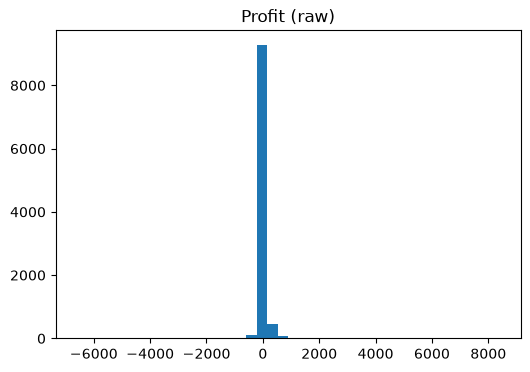

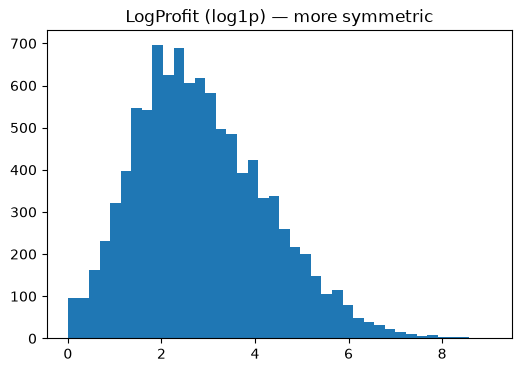

In [9]:
# 1) Histograms: Profit vs LogProfit
plt.figure(figsize=(6,4))
plt.hist(df['Profit'].dropna(), bins=40)
plt.title("Profit (raw)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['LogProfit'].dropna(), bins=40)
plt.title("LogProfit (log1p) — more symmetric")
plt.show()

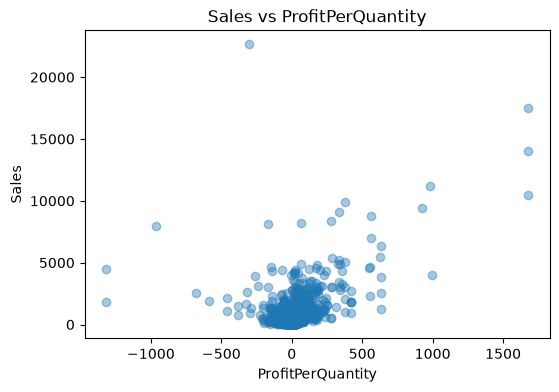

In [10]:
# 2) Relationship: Sales vs ProfitPerQuantity
plt.figure(figsize=(6,4))
plt.scatter(df['ProfitPerQuantity'], df['Sales'], alpha=0.4)
plt.xlabel("ProfitPerQuantity")
plt.ylabel("Sales")
plt.title("Sales vs ProfitPerQuantity")
plt.show()

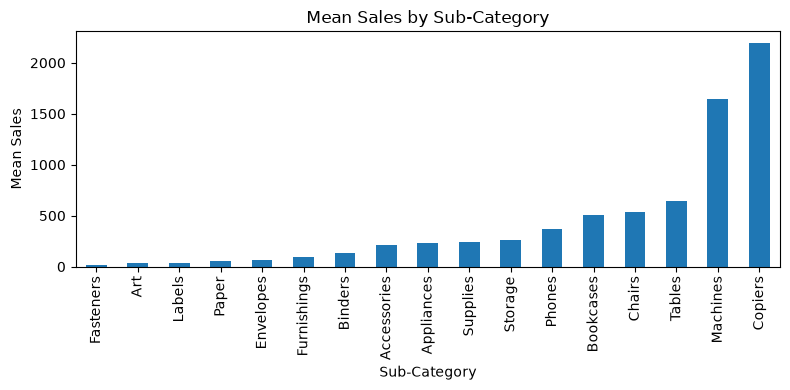

In [11]:
# 3) Group means: Sales by Sub-Category
means = df.groupby('Sub-Category')['Sales'].mean().sort_values()
plt.figure(figsize=(8,4))
means.plot(kind='bar')
plt.title("Mean Sales by Sub-Category")
plt.ylabel("Mean Sales")
plt.tight_layout()
plt.show()

## 5. Students' practice
* Try to improve the model performance using feature engineering and adding new variables in the dataset

